# Weighted rating and simulated attack

Compare the plain average with the weighted rating, then test both against a mass-rating attack: bots post many ratings at once, but nobody marks their reviews as helpful (0 votes), so each bot gets the minimum weight of 0.1.

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

from data_cleaning import load_and_clean
from simulation import compare_ratings, simulate_attack

df = load_and_clean()

Loaded 2961 rows, kept 2761 with a valid rating, (200 dropped).


## Plain vs weighted rating (real reviews)

In [4]:
pd.Series(compare_ratings(df)).round(2)

plain       8.85
weighted    8.92
dtype: float64

On the real reviews the two ratings are almost the same (**8.85** vs **8.92**): the weighting does not change honest opinion much.

## Attack: fake 1-star reviews ("haters")

In [8]:
haters = simulate_attack(df, sizes=[0, 100, 500, 1000, 2000], rating=1)
haters.assign(plain_drop=haters["plain"].iloc[0] - haters["plain"],
              weighted_drop=haters["weighted"].iloc[0] - haters["weighted"]).round(2)

,plain,weighted,plain_drop,weighted_drop
fake_reviews,,,,
0,8.85,8.92,0.00,0.00
100,8.57,8.80,0.27,0.11
500,7.64,8.39,1.20,0.53
1000,6.76,7.92,2.09,0.99
2000,5.55,7.15,3.30,1.77


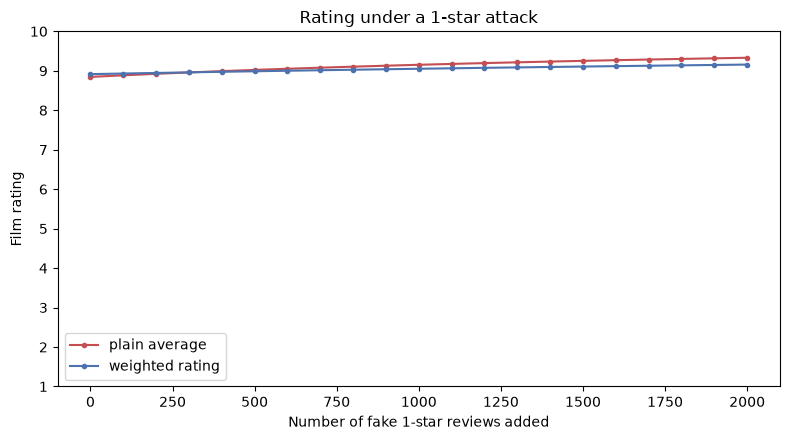

In [ ]:
curve = simulate_attack(df, sizes=range(0, 2001, 100), rating=1)

ax = curve.plot(figsize=(8, 4.5), color=["#C44E52", "#4C72B0"], marker="o", markersize=3)
ax.set_xlabel("Number of fake 1-star reviews added")
ax.set_ylabel("Film rating")
ax.set_ylim(1, 10)
ax.set_title("Rating under a 1-star attack")
ax.legend(["plain average", "weighted rating"])
ax.figure.tight_layout()
plt.show()

- **500 fake 1s** pull the plain average down by **1.20** (8.85 → 7.64) but the weighted rating by only **0.53** (8.92 → 8.39).
- At every attack size the weighted rating loses roughly **half as much** as the plain average, because each bot counts as 0.1 of a person.
- The effect is reduced, not removed.

## Attack: fake 10-star reviews ("fans")

In [7]:
fans = simulate_attack(df, sizes=[0, 100, 500, 1000, 2000], rating=10)
fans.assign(plain_rise=fans["plain"] - fans["plain"].iloc[0],
            weighted_rise=fans["weighted"] - fans["weighted"].iloc[0]).round(2)

,plain,weighted,plain_rise,weighted_rise
fake_reviews,,,,
0,8.85,8.92,0.00,0.00
100,8.89,8.93,0.04,0.02
500,9.02,8.99,0.18,0.07
1000,9.15,9.05,0.31,0.14
2000,9.33,9.16,0.49,0.24


The same holds for a fan attack: 500 fake 10s raise the plain average by 0.18 and the weighted rating by 0.07. The changes are small in both cases because the film's rating is already close to 10.

## Limitations

- **Helpfulness votes can be faked too.** Bots that mark each other's reviews as helpful would gain weight. The data does not say who cast the votes, so this cannot be detected here.
- **New honest reviews start at the minimum weight** until readers vote on them.
- **"Helpful" often means "I agree".** For a well-liked film, negative reviews get voted down, so the weighting leans towards the majority opinion.